# Simple Chain

In [1]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from PIL import Image

# Set your API key
os.environ["OPENROUTER_API_KEY"] = ""

In [2]:
# Example network link data
network_links = """
Link A-B: bandwidth=100Mbps, utilization=92%, latency=45ms, packet_loss=2.1%
Link B-C: bandwidth=100Mbps, utilization=40%, latency=10ms, packet_loss=0.1%
Link C-D: bandwidth=1Gbps, utilization=87%, latency=60ms, packet_loss=1.5%
Link D-E: bandwidth=500Mbps, utilization=55%, latency=20ms, packet_loss=0.2%
Link E-F: bandwidth=100Mbps, utilization=96%, latency=80ms, packet_loss=3.4%
"""

In [3]:
# Create LLM
# Create LLM using OpenRouter
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    temperature=0.5,
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1"
)

In [4]:
# llm = ChatOpenAI(
#     model="gpt-5-nano",
#     # stream_usage=True, # Whether to include usage metadata in streaming output
#     # temperature=None,
#     # max_tokens=None,
#     # timeout=None,
#     # reasoning_effort="low",
#     # max_retries=2,
#     # api_key="...",  # If you prefer to pass api key in directly
#     # base_url="...",
#     # organization="...",
#     # other params...
# )

In [5]:
# First prompt: detect congested links
detect_prompt = ChatPromptTemplate.from_template("""
You are a network monitoring assistant.

Given the following network links, identify the congested links.

A link is congested if it has high utilization, high latency, or packet loss.

Network links:
{network_links}

Return only a clear bullet list of congested links with the reason.
""")

In [6]:
# Second prompt: summarize network state
summary_prompt = ChatPromptTemplate.from_template("""
You are a network operations expert.

The following links were detected as congested:

{congested_links}

Write one short paragraph summarizing the overall state of the network.
Include possible impact on users or applications.
""")

In [7]:
# First LLM call
detect_chain = detect_prompt | llm  # llm.invoke(detect_prompt.invoke(input))
congested_result = detect_chain.invoke({
    "network_links": network_links
})

congested_links = congested_result.content

print("Congested Links:")
print(congested_links)

Congested Links:
- **Link A-B**: 
  - Utilization = 92% (high utilization)
  - Latency = 45ms (high latency)
  - Packet Loss = 2.1% (packet loss)

- **Link C-D**: 
  - Utilization = 87% (high utilization)
  - Latency = 60ms (high latency)
  - Packet Loss = 1.5% (packet loss)

- **Link E-F**: 
  - Utilization = 96% (high utilization)
  - Latency = 80ms (high latency)
  - Packet Loss = 3.4% (packet loss)


In [8]:
# Second LLM call
summary_chain = summary_prompt | llm
summary_result = summary_chain.invoke({
    "congested_links": congested_links
})

print("\nNetwork Summary:")
print(summary_result.content)


Network Summary:
The current state of the network is concerning, with all monitored links experiencing high utilization and significant latency, which can severely impact user experience and application performance. Link A-B shows a utilization of 92% with a latency of 45ms and 2.1% packet loss, while Link C-D has 87% utilization, 60ms latency, and 1.5% packet loss. Link E-F is particularly problematic, operating at 96% utilization, 80ms latency, and 3.4% packet loss. This level of congestion can lead to slow application response times, increased delays in data transmission, and potential disruptions in critical services, adversely affecting end-users' ability to efficiently access resources and communicate over the network. Immediate attention is required to alleviate congestion and improve overall performance.


# LangGraph Implementation

In [9]:
from langgraph.graph import StateGraph, START, END

In [10]:
import os
from typing import TypedDict

In [11]:
# Define graph state
class NetworkState(TypedDict):
    network_links: str
    congested_links: str
    network_summary: str

In [12]:
# Node 1: detect congested links
def detect_congestion(state: NetworkState):
    chain = detect_prompt | llm

    result = chain.invoke({
        "network_links": state["network_links"]
    })

    return {
        "congested_links": result.content
    }


# Node 2: summarize network state
def summarize_network(state: NetworkState):
    chain = summary_prompt | llm

    result = chain.invoke({
        "congested_links": state["congested_links"]
    })

    return {
        "network_summary": result.content
    }

In [13]:
# Build LangGraph
graph_builder = StateGraph(NetworkState)

graph_builder.add_node("detect_congestion", detect_congestion)
graph_builder.add_node("summarize_network", summarize_network)

graph_builder.add_edge(START, "detect_congestion")
graph_builder.add_edge("detect_congestion", "summarize_network")
graph_builder.add_edge("summarize_network", END)

app = graph_builder.compile()

In [14]:
def draw_graph(app):
    graph = app.get_graph()

    # Save as Mermaid text
    mermaid_code = graph.draw_mermaid()


    # Save as PNG
    png_data = graph.draw_mermaid_png()

    with open("results/agent_chain.png", "wb") as f:
        f.write(png_data)

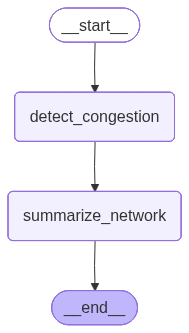

In [15]:
draw_graph(app)

Image.open("results/agent_chain.png").convert("RGB")

In [16]:
# Run the graph
result = app.invoke({
    "network_links": network_links,
    "congested_links": "",
    "network_summary": ""
})


# Print results
print("Congested Links:")
print(result["congested_links"])

print("\nNetwork Summary:")
print(result["network_summary"])

Congested Links:
- **Link A-B**: 
  - Utilization: 92% (high)
  - Latency: 45ms (high)
  - Packet Loss: 2.1% (high)

- **Link C-D**: 
  - Utilization: 87% (high)
  - Latency: 60ms (high)
  - Packet Loss: 1.5% (high)

- **Link E-F**: 
  - Utilization: 96% (high)
  - Latency: 80ms (high)
  - Packet Loss: 3.4% (high)

Network Summary:
The network is currently experiencing significant congestion across multiple links, with utilization levels exceeding 85% on all monitored connections, particularly Link E-F at a concerning 96%. This high utilization is accompanied by elevated latency, peaking at 80ms on Link E-F, and packet loss rates above 1%, which can severely degrade user experience and application performance. Users may encounter delays in data transmission, interruptions in service, and reduced responsiveness in real-time applications, potentially leading to frustration and decreased productivity. Immediate attention is required to alleviate the congestion and restore optimal network 

# Structured Data Implementation
    

In [17]:
network_links = [
    {
        "link": "A-B",
        "bandwidth": "100Mbps",
        "utilization": 92,
        "latency_ms": 45,
        "packet_loss_percent": 2.1,
        "enabled": 1,
    },
    {
        "link": "B-C",
        "bandwidth": "100Mbps",
        "utilization": 40,
        "latency_ms": 10,
        "packet_loss_percent": 0.1,
        "enabled": 1,
    },
    {
        "link": "C-D",
        "bandwidth": "1Gbps",
        "utilization": 87,
        "latency_ms": 60,
        "packet_loss_percent": 1.5,
        "enabled": 1,
    },
    {
        "link": "D-E",
        "bandwidth": "500Mbps",
        "utilization": 55,
        "latency_ms": 20,
        "packet_loss_percent": 0.2,
        "enabled": 1,
    },
    {
        "link": "E-F",
        "bandwidth": "100Mbps",
        "utilization": 96,
        "latency_ms": 80,
        "packet_loss_percent": 3.4,
        "enabled": 1,
    }
]

In [18]:
from typing import TypedDict, List

class LinkData(TypedDict):
    link: str
    bandwidth: str
    utilization: int
    latency_ms: int
    packet_loss_percent: float
    enabled: int


class NetworkState(TypedDict):
    network_links: List[LinkData]
    congested_links: str
    network_summary: str

In [19]:
def detect_congestion(state: NetworkState):
    network_links_text = format_network_links(state["network_links"])

    chain = detect_prompt | llm

    result = chain.invoke({
        "network_links": network_links_text
    })

    return {
        "congested_links": result.content
    }

In [20]:
def format_network_links(links):
    return "\n".join(
        f"Link {link['link']}: "
        f"bandwidth={link['bandwidth']}, "
        f"utilization={link['utilization']}%, "
        f"latency={link['latency_ms']}ms, "
        f"packet_loss={link['packet_loss_percent']}%"
        for link in links
    )

In [21]:
# Build LangGraph
graph_builder = StateGraph(NetworkState)

graph_builder.add_node("detect_congestion", detect_congestion)
graph_builder.add_node("summarize_network", summarize_network)

graph_builder.add_edge(START, "detect_congestion")
graph_builder.add_edge("detect_congestion", "summarize_network")
graph_builder.add_edge("summarize_network", END)

app = graph_builder.compile()

In [22]:
# Run the graph
result = app.invoke({
    "network_links": network_links,
    "congested_links": "",
    "network_summary": ""
})


# Print results
print("Congested Links:")
print(result["congested_links"])

print("\nNetwork Summary:")
print(result["network_summary"])

Congested Links:
- **Link A-B**: 
  - Utilization: 92% (high utilization)
  - Latency: 45ms (considered high)
  - Packet Loss: 2.1% (packet loss)

- **Link C-D**: 
  - Utilization: 87% (high utilization)
  - Latency: 60ms (considered high)
  - Packet Loss: 1.5% (packet loss)

- **Link E-F**: 
  - Utilization: 96% (high utilization)
  - Latency: 80ms (considered high)
  - Packet Loss: 3.4% (packet loss)

Network Summary:
The current state of the network is concerning, with three links—A-B, C-D, and E-F—experiencing high utilization rates ranging from 87% to 96%, accompanied by elevated latency levels and packet loss. Link E-F is particularly critical, exhibiting the highest utilization and latency, which could severely impact user experience by causing delays and interruptions in applications, especially those requiring real-time data transmission, such as video conferencing or online gaming. The packet loss across all links suggests that data integrity may be compromised, potentially l

# Take Action

In [23]:
from langchain_core.tools import tool

In [24]:
class NetworkState(TypedDict):
    network_links: List[LinkData]
    congested_link_ids: List[str]
    congested_links: str
    network_summary: str
    change_result: str

In [25]:
def extract_json(text: str) -> dict:
    """
    Extract JSON from an LLM response, even if it is wrapped in markdown.
    """
    text = text.strip()

    text = re.sub(r"```json", "", text)
    text = re.sub(r"```", "", text)
    text = text.strip()

    return json.loads(text)

In [26]:
def change_node_state(state: NetworkState, node: str) -> str:
    """
    Disable a network link by changing enabled from 1 to 0.
    """

    for link in state["network_links"]:
        if link["link"] == node:
            old_value = link["enabled"]
            link["enabled"] = 0

            message = (
                f"Link {node} changed: enabled {old_value} -> {link['enabled']}"
            )

            print(message)
            return message

    message = f"Link {node} not found."
    print(message)
    return message

In [27]:
detect_prompt = ChatPromptTemplate.from_template("""
You are a network monitoring assistant.

Given the following network links, identify congested links.

A link is congested if it has:
- utilization above 85%
- latency above 50ms
- packet loss above 1%

Network links:
{network_links}

Return ONLY valid JSON in this format:

{{
  "congested_link_ids": ["A-B", "C-D"],
  "congested_links": "- Link A-B: reason here\\n- Link C-D: reason here"
}}
""")


summary_prompt = ChatPromptTemplate.from_template("""
You are a network operations expert.

The following links were detected as congested:

{congested_links}

Write one short paragraph summarizing the overall network state.
Include possible impact on users or applications.
""")

In [28]:
disable_prompt = ChatPromptTemplate.from_template("""
You are a network automation agent.

The following links are congested:

{congested_link_ids}

You must call the available tool once for each congested link.
Use the exact link name as the node argument.

Do not disable healthy links.
""")

In [29]:
def detect_congestion(state: NetworkState):
    network_links_text = format_network_links(state["network_links"])

    chain = detect_prompt | llm

    result = chain.invoke({
        "network_links": network_links_text
    })

    parsed = extract_json(result.content)

    return {
        "congested_link_ids": parsed["congested_link_ids"],
        "congested_links": parsed["congested_links"]
    }


def summarize_network(state: NetworkState):
    chain = summary_prompt | llm

    result = chain.invoke({
        "congested_links": state["congested_links"]
    })

    return {
        "network_summary": result.content
    }


def disable_congested_links(state: NetworkState):
    """
    This node creates a tool that wraps change_node_state.
    The LLM calls the tool for each congested link.
    """

    @tool
    def change_node_state_tool(node: str) -> str:
        """
        Disable a congested network link.

        Args:
            node: The link name, for example A-B or C-D.
        """
        return change_node_state(state, node)

    llm_with_tools = llm.bind_tools([change_node_state_tool])

    chain = disable_prompt | llm_with_tools

    response = chain.invoke({
        "congested_link_ids": state["congested_link_ids"]
    })

    tool_results = []

    if response.tool_calls:
        for tool_call in response.tool_calls:
            if tool_call["name"] == "change_node_state_tool":
                tool_result = change_node_state_tool.invoke(tool_call["args"])
                tool_results.append(tool_result)
    else:
        tool_results.append("No tool calls were made by the LLM.")

    return {
        "network_links": state["network_links"],
        "change_result": "\n".join(tool_results)
    }


In [30]:
graph_builder = StateGraph(NetworkState)

graph_builder.add_node("detect_congestion", detect_congestion)
graph_builder.add_node("summarize_network", summarize_network)
graph_builder.add_node("disable_congested_links", disable_congested_links)

graph_builder.add_edge(START, "detect_congestion")
graph_builder.add_edge("detect_congestion", "summarize_network")
graph_builder.add_edge("summarize_network", "disable_congested_links")
graph_builder.add_edge("disable_congested_links", END)

app = graph_builder.compile()

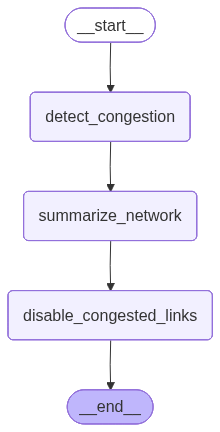

In [31]:
draw_graph(app)

Image.open("results/agent_chain.png").convert("RGB")

In [32]:
import os
import json
import re
from typing import TypedDict, List


result = app.invoke({
    "network_links": network_links,
    "congested_link_ids": [],
    "congested_links": "",
    "network_summary": "",
    "change_result": ""
})

Link A-B changed: enabled 1 -> 0
Link C-D changed: enabled 1 -> 0
Link E-F changed: enabled 1 -> 0


In [33]:
print("\nCongested Link IDs:")
print(result["congested_link_ids"])

print("\nCongested Links:")
print(result["congested_links"])

print("\nNetwork Summary:")
print(result["network_summary"])

print("\nTool Change Result:")
print(result["change_result"])

print("\nFinal Network Links:")
for link in result["network_links"]:
    print(link)


Congested Link IDs:
['A-B', 'C-D', 'E-F']

Congested Links:
- Link A-B: utilization above 85%, packet loss above 1%
- Link C-D: utilization above 85%, latency above 50ms, packet loss above 1%
- Link E-F: utilization above 85%, latency above 50ms, packet loss above 1%

Network Summary:
The overall network state is concerning, with three links—A-B, C-D, and E-F—experiencing significant congestion characterized by high utilization (above 85%), packet loss (above 1%), and in the cases of links C-D and E-F, elevated latency (above 50ms). This congestion can lead to degraded performance for users and applications, resulting in slow response times, increased delays in data transmission, and potential disruptions in critical services. Users may experience dropped connections, buffering during media streaming, and overall reduced application responsiveness, which could negatively impact productivity and user satisfaction. Immediate attention is required to alleviate the congestion and restore 

# RAG

In [34]:
import re
from typing import List, Dict
from langchain_core.prompts import ChatPromptTemplate

# Optional: enrich with real docs/playbooks later
knowledge_docs = [
    """
    Congestion response policy:
    - If utilization > 85%, classify as high congestion.
    - If latency > 50ms and packet_loss > 1%, classify as degraded link quality.
    - Prefer traffic reroute before disabling links.
    - Only disable links when redundancy is available.
    """,
    """
    Incident playbook:
    1) Detect affected links.
    2) Check redundancy path health.
    3) Notify NOC before state change.
    4) Apply change.
    5) Verify latency/utilization recovery.
    """,
    """
    SLA guidance:
    - Packet loss above 1% may impact voice/video traffic.
    - Latency above 80ms significantly affects interactive apps.
    - Prioritize remediation for links serving critical apps.
    """
]

def chunk_text(text: str, chunk_size: int = 320, overlap: int = 60) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    chunks = []
    i = 0
    while i < len(text):
        chunks.append(text[i:i + chunk_size])
        i += max(1, chunk_size - overlap)
    return chunks

In [35]:
kb_chunks = []
for doc in knowledge_docs:
    kb_chunks.extend(chunk_text(doc, chunk_size=320))

for x_ind, x in enumerate(kb_chunks):
    print(f'Chunk #{x_ind + 1}:\n {x} \n')

Chunk #1:
 Congestion response policy: - If utilization > 85%, classify as high congestion. - If latency > 50ms and packet_loss > 1%, classify as degraded link quality. - Prefer traffic reroute before disabling links. - Only disable links when redundancy is available. 

Chunk #2:
 Incident playbook: 1) Detect affected links. 2) Check redundancy path health. 3) Notify NOC before state change. 4) Apply change. 5) Verify latency/utilization recovery. 

Chunk #3:
 SLA guidance: - Packet loss above 1% may impact voice/video traffic. - Latency above 80ms significantly affects interactive apps. - Prioritize remediation for links serving critical apps. 



In [36]:
kb_chunks = []
for doc in knowledge_docs:
    kb_chunks.extend(chunk_text(doc, chunk_size=200))

for x_ind, x in enumerate(kb_chunks):
    print(f'Chunk #{x_ind + 1}:\n {x} \n')

Chunk #1:
 Congestion response policy: - If utilization > 85%, classify as high congestion. - If latency > 50ms and packet_loss > 1%, classify as degraded link quality. - Prefer traffic reroute before disabling  

Chunk #2:
 ded link quality. - Prefer traffic reroute before disabling links. - Only disable links when redundancy is available. 

Chunk #3:
 Incident playbook: 1) Detect affected links. 2) Check redundancy path health. 3) Notify NOC before state change. 4) Apply change. 5) Verify latency/utilization recovery. 

Chunk #4:
 latency/utilization recovery. 

Chunk #5:
 SLA guidance: - Packet loss above 1% may impact voice/video traffic. - Latency above 80ms significantly affects interactive apps. - Prioritize remediation for links serving critical apps. 

Chunk #6:
 ze remediation for links serving critical apps. 



In [37]:
kb_chunks = []
for doc in knowledge_docs:
    kb_chunks.extend(chunk_text(doc, overlap=100))

for x_ind, x in enumerate(kb_chunks):
    print(f'Chunk #{x_ind + 1}:\n {x} \n')

Chunk #1:
 Congestion response policy: - If utilization > 85%, classify as high congestion. - If latency > 50ms and packet_loss > 1%, classify as degraded link quality. - Prefer traffic reroute before disabling links. - Only disable links when redundancy is available. 

Chunk #2:
 e links when redundancy is available. 

Chunk #3:
 Incident playbook: 1) Detect affected links. 2) Check redundancy path health. 3) Notify NOC before state change. 4) Apply change. 5) Verify latency/utilization recovery. 

Chunk #4:
 SLA guidance: - Packet loss above 1% may impact voice/video traffic. - Latency above 80ms significantly affects interactive apps. - Prioritize remediation for links serving critical apps. 



In [38]:
def tokenize(s: str) -> set:
    return set(re.findall(r"[a-zA-Z0-9\-_]+", s.lower()))

def retrieve_chunks(query: str, chunks: List[str], k: int = 3) -> List[Dict]:
    q = tokenize(query)
    scored = []
    for c in chunks:
        t = tokenize(c)
        # very simple score: overlap count
        score = len(q.intersection(t))
        scored.append({"chunk": c, "score": score})
    scored.sort(key=lambda x: x["score"], reverse=True)
    return [x for x in scored[:k] if x["score"] > 0]

In [39]:
rag_prompt = ChatPromptTemplate.from_template("""
You are a network operations assistant.

Use ONLY the retrieved context to answer.
If context is insufficient, say "I don't have enough context."

Question:
{question}

Retrieved context:
{context}

Answer clearly and briefly.
""")

def rag_answer(question: str) -> str:
    top = retrieve_chunks(question, kb_chunks, k=3)
    context = "\n\n---\n\n".join([x["chunk"] for x in top]) if top else "No relevant context found."
    chain = rag_prompt | llm
    out = chain.invoke({"question": question, "context": context})
    return out.content

In [40]:
q1 = "When should we disable a congested link?"
q2 = "What user impact should we expect when packet loss is above 1%?"

print("Q:", q1)
print(rag_answer(q1))
print("\nQ:", q2)
print(rag_answer(q2))

Q: When should we disable a congested link?
You should disable a congested link only when redundancy is available.

Q: What user impact should we expect when packet loss is above 1%?
When packet loss is above 1%, we should expect an impact on voice and video traffic.
